In [1]:
import os
import cv2
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import shutil
from ultralytics import YOLO

In [2]:
model = YOLO("yolov11n-face.pt")

In [ ]:
def remove_face(card):
    result = model.predict(card, imgsz=256, conf=0.5)[0]
    boxes = [box.cpu().numpy() for box in result.boxes.xyxy]
    for corners in boxes:
        corners = corners.reshape((2,2))
        center = np.mean(corners, axis=0)
        corners = center + (corners - center) * 1.3
        mask = np.ones_like(card) * 255
        mask = cv2.rectangle(mask, (int(corners[0,0]), int(corners[0,1])), (int(corners[1,0]), int(corners[1,1])), (0, 0, 0), -1)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        card = cv2.bitwise_and(card, card, mask=mask)
    return card

In [ ]:
CARD = 'card'
TEMPLATE = 'template'

In [5]:
templates = []
for file in os.listdir(TEMPLATE):
    temp = cv2.imread(os.path.join(TEMPLATE, file))
    temp = cv2.cvtColor(temp, cv2.COLOR_BGR2RGB)
    templates.append(cv2.resize(temp, (256, 256)))

templates = np.array(templates)

In [6]:
triple_templates = []
for template in templates:
    brighter_template = template.copy()
    brighter_template = cv2.cvtColor(brighter_template, cv2.COLOR_RGB2HSV)
    brighter_template[:, :, 2] = cv2.add(brighter_template[:, :, 2], 50)
    brighter_template = cv2.cvtColor(brighter_template, cv2.COLOR_HSV2RGB)
    darker_template = template.copy()
    darker_template = cv2.cvtColor(darker_template, cv2.COLOR_RGB2HSV)
    darker_template[:, :, 2] = cv2.add(darker_template[:, :, 2], -50)
    darker_template = cv2.cvtColor(darker_template, cv2.COLOR_HSV2RGB)
    triple_templates.append((darker_template, template, brighter_template))

In [7]:
normalized_grayscale_template = []
for template in templates:
    gray_image = cv2.cvtColor(template, cv2.COLOR_RGB2GRAY)
    normalized = cv2.normalize(gray_image, None, 0, 255, cv2.NORM_MINMAX)
    normalized_grayscale_template.append(normalized)

In [8]:
normalized_template = []
for template in templates:
    hsv = cv2.cvtColor(template, cv2.COLOR_RGB2HSV)
    hsv[:,:,2] = cv2.normalize(hsv[:,:,2], None, 0, 255, cv2.NORM_MINMAX)
    normalized_template.append(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))

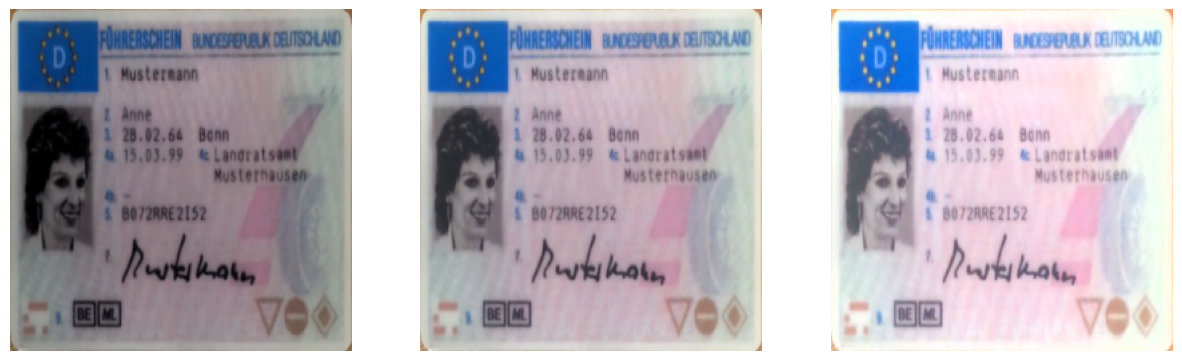

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for i in range(3):
    axes[i].imshow(triple_templates[0][i])
    axes[i].axis('off')

plt.show()

In [116]:
def match_triple(img, templates):
    results = np.zeros(len(templates))
    for i in range(len(templates)):
        print(i)
        dark, normal, bright = templates[i]
        dark_result = cv2.matchTemplate(img, dark, cv2.TM_CCOEFF_NORMED)[0,0]
        normal_result = cv2.matchTemplate(img, normal, cv2.TM_CCOEFF_NORMED)[0,0]
        bright_result = cv2.matchTemplate(img, bright, cv2.TM_CCOEFF_NORMED)[0,0]
        results[i] = np.max([dark_result, normal_result, bright_result])
    return results

In [11]:
def match_grayscale(img, templates):
    results = np.zeros(len(templates))
    for i in range(len(templates)):
        gray_image = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        normalized = cv2.normalize(gray_image, None, 0, 255, cv2.NORM_MINMAX)
        results[i] = cv2.matchTemplate(normalized, templates[i], cv2.TM_CCOEFF_NORMED)[0,0]
        
    return results

In [12]:
def match_normalized(img, templates):
    results = np.zeros(len(templates))
    for i in range(len(templates)):
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        hsv[:,:,2] = cv2.normalize(hsv[:,:,2], None, 0, 255, cv2.NORM_MINMAX)
        results[i] = cv2.matchTemplate(hsv, templates[i], cv2.TM_CCOEFF_NORMED)[0,0]
    
    return results

In [13]:
def match(img, templates):
    results = np.zeros(len(templates))
    for i in range(len(templates)):
        result = cv2.matchTemplate(img, templates[i], cv2.TM_CCOEFF_NORMED)[0,0]
        results[i] = result
    return results

In [14]:
triple_results = []
gray_results = []
norm_results = []
results = []
ground_truth = []

for gt in os.listdir(CARD):
    card_folder = os.path.join(CARD, str(gt))
    for file in os.listdir(card_folder):
        card = cv2.imread(os.path.join(card_folder, file))
        card = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)
        card = cv2.resize(card, (256, 256))
        triple_results.append(match_triple(card, triple_templates))
        gray_results.append(match_grayscale(card, normalized_grayscale_template))
        norm_results.append(match_normalized(card, normalized_template))
        results.append(match(card, templates))
        ground_truth.append(int(gt))

triple_results = np.array(triple_results)
gray_results = np.array(gray_results)
norm_results = np.array(norm_results)
results = np.array(results)
ground_truth = np.array(ground_truth)

In [15]:
triple_labels = np.argmax(triple_results, axis=1)
triple_score = np.max(triple_results, axis=1)
gray_labels = np.argmax(gray_results, axis=1)
gray_score = np.max(gray_results, axis=1)
norm_labels = np.argmax(norm_results, axis=1)
norm_score = np.max(norm_results, axis=1)
labels = np.argmax(results, axis=1)
score = np.max(results, axis=1)

In [42]:
threshold = 0.6

In [43]:
recognized = np.where(triple_score > threshold, 1, 0)

In [44]:
card_dir = "data/yolo_output/card" 
unrecognized_results = []

for file in os.listdir(card_dir):
    number = int(file[5:-4])
    if number < 601: continue
    card = cv2.imread(os.path.join(card_dir, file))
    card = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)
    card = cv2.resize(card, (256, 256))
    result = match_triple(card, triple_templates)
    unrecognized_results.append(result)

unrecognized_results = np.array(unrecognized_results)

In [45]:
unrecognized_labels = np.argmax(unrecognized_results, axis=1)
unrecognized_score = np.max(unrecognized_results, axis=1)
unrecognized = np.where(unrecognized_score > threshold, 1, 0)

In [46]:
TP = np.sum(recognized)
TN = np.sum(unrecognized == 0)
FN = np.sum(recognized == 0)
FP = np.sum(unrecognized)
print(TP, TN, FP, FN)

PRECISION = TP / (TP + FP)
RECALL = TP / (TP + FN)
F1 = (2 * PRECISION * RECALL) / (PRECISION + RECALL)
print(F1)

270 383 17 12
0.9490333919156415


In [47]:
print(PRECISION, RECALL)

0.9407665505226481 0.9574468085106383


In [48]:
TEMPLATE2 = 'template2'
CARD2 = 'prediction'

In [81]:
templates2 = []
for i in range(len(os.listdir(TEMPLATE2))):
    temp = cv2.imread(os.path.join(TEMPLATE2, str(i) + '.jpg'))
    temp = cv2.cvtColor(temp, cv2.COLOR_BGR2RGB)
    temp = cv2.resize(temp, (256, 256))
    # temp = remove_face(temp)
    templates2.append(temp)

templates2 = np.array(templates2)

In [ ]:
triple_templates2 = []
for template in templates2:
    brighter_template = template.copy()
    brighter_template = cv2.cvtColor(brighter_template, cv2.COLOR_RGB2HSV)
    brighter_template[:, :, 2] = cv2.add(brighter_template[:, :, 2], 70)
    brighter_template = cv2.cvtColor(brighter_template, cv2.COLOR_HSV2RGB)
    darker_template = template.copy()
    darker_template = cv2.cvtColor(darker_template, cv2.COLOR_RGB2HSV)
    darker_template[:, :, 2] = cv2.add(darker_template[:, :, 2], -70)
    darker_template = cv2.cvtColor(darker_template, cv2.COLOR_HSV2RGB)
    template = remove_face(template)
    brighter_template = remove_face(brighter_template)
    darker_template = remove_face(darker_template)
    triple_templates2.append((darker_template, template, brighter_template))

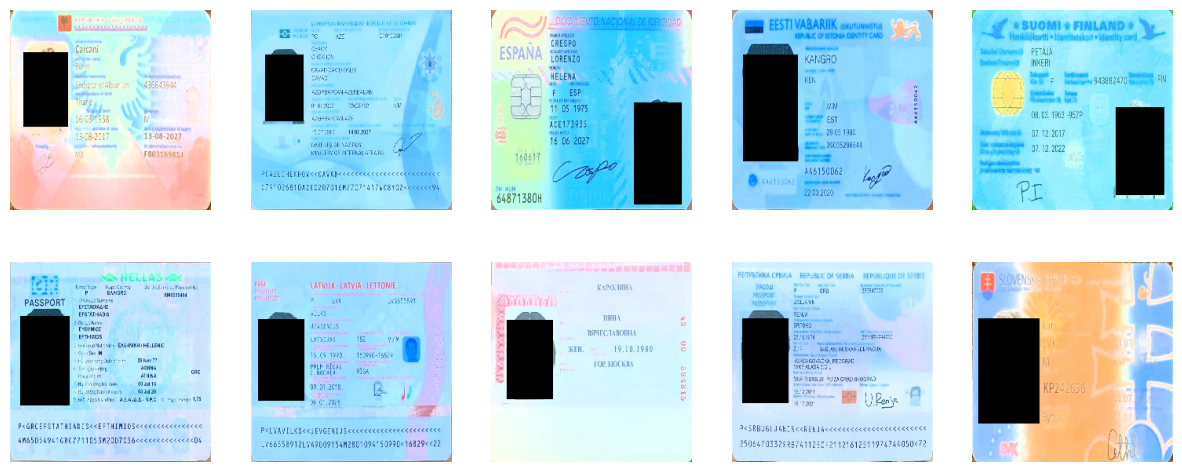

In [51]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(len(triple_templates2)):
    axes[i//5, i%5].imshow(triple_templates2[i][2])
    axes[i//5, i%5].axis('off')

plt.show()

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(len(os.listdir(CARD2))):
    subfolder = os.path.join(CARD2, str(i))
    file = os.listdir(subfolder)[0]
    card = cv2.imread(os.path.join(subfolder, file))
    card = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)
    card = cv2.resize(card, (256, 256))
    card = remove_face(card)
    axes[i//5, i%5].imshow(card)
    axes[i//5, i%5].axis('off')

plt.show()    

In [ ]:
results2 = []
ground_truth2 = []
cards = []

for i in range(len(os.listdir(CARD2))):
    subfolder = os.path.join(CARD2, str(i))
    for file in os.listdir(subfolder):
        if os.path.isfile(os.path.join(subfolder, file)) == False: continue
        card = cv2.imread(os.path.join(subfolder, file))
        card = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)
        card = cv2.resize(card, (256, 256))
        card = remove_face(card)
        cards.append(card)
        results2.append(match_triple(card, triple_templates2))
        ground_truth2.append(int(i))

results2 = np.array(results2)
ground_truth2 = np.array(ground_truth2)


In [83]:
print(results2)

[[    0.80574      0.5848     0.12704 ...     0.50562     0.49309     0.24823]
 [    0.83422     0.56845    0.089399 ...     0.48908     0.46799     0.24802]
 [    0.88601     0.58605    0.087663 ...     0.53891     0.50708     0.29058]
 ...
 [    0.38849     0.36307    -0.18497 ...     0.60754     0.58223           1]
 [    0.37956      0.3558    -0.14698 ...     0.56883     0.53458      0.8961]
 [    0.39786     0.33049   0.0042714 ...      0.5058     0.48456      0.7769]]


In [84]:
threshold = 0.7

In [85]:
labels2 = np.argmax(results2, axis=1)
score2 = np.max(results2, axis=1)

recognized2 = np.where(score2 > threshold, 1, 0)

In [86]:
print(labels2)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 8 5 5 5 5 5 8 5 5 5 8 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7 7 7 7
 7 7 7 7 7 7 7 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9 9 9]


In [87]:
print(score2)

[    0.80574     0.83422     0.88601      0.8808     0.73207     0.81107     0.84304     0.82106     0.80982     0.85398     0.84325      0.8184     0.75616      0.7096     0.70525     0.79542     0.85342     0.74768     0.73064     0.83112      0.8224     0.80848     0.84506     0.78393     0.82203     0.81981
      0.8298     0.89942           1     0.86092     0.80322     0.79516      0.8485     0.75839     0.80322     0.79107           1     0.81726     0.80679     0.75053     0.79331      0.8195     0.78254     0.80245     0.80306     0.82933     0.82465     0.70576     0.69208     0.74329     0.80361     0.75284
     0.76632     0.75306     0.72452     0.88117     0.83453     0.79522     0.80951     0.83698     0.85588     0.86727     0.84817     0.82482     0.74118      0.7199     0.82299     0.79725     0.80282      0.7941     0.80486     0.77485     0.76342     0.79775     0.80624     0.70693     0.81196     0.89276
     0.89548     0.87627     0.88659     0.88565     0.88997 

In [88]:
print(np.sum(recognized2) / recognized2.shape[0])

0.9890710382513661


In [89]:
labels2 = np.where(score2 > threshold, labels2, 10)
accuracy = np.sum(labels2 == ground_truth2) / len(ground_truth2)
print(accuracy)

0.9726775956284153


In [80]:
missclassified = np.where(labels2 != ground_truth2)[0]

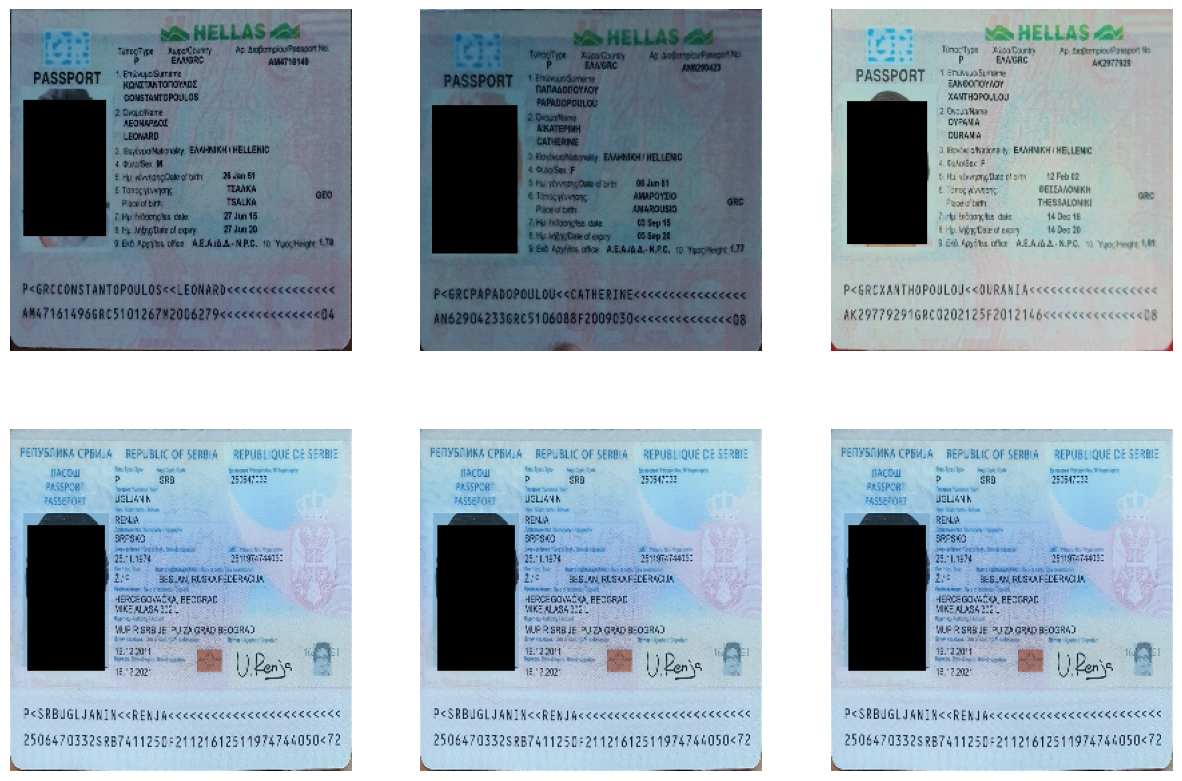

In [112]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i in range(3):
    axes[0, i%3].imshow(cards[missclassified[i]])
    axes[1, i%3].imshow(triple_templates2[labels2[missclassified[i]]][1])
    axes[0, i%3].axis('off')
    axes[1, i%3].axis('off')
plt.show()

In [110]:
for i in range(3):
    print(match_triple(cards[missclassified[i]], triple_templates2))

[    0.56579     0.53389   -0.024457     0.55536   -0.050212     0.69638     0.68595     0.62281      0.7049     0.47103]
[    0.51223     0.44335   -0.060974     0.61277   -0.081485     0.76357     0.73469     0.66698     0.76759     0.54724]
[    0.60102     0.53727   -0.073491     0.64416    -0.10136      0.7946     0.76065     0.74519      0.8174     0.56145]


In [99]:
print(np.sum(recognized2) / recognized2.shape[0])

0.9890710382513661


0: 256x256 1 face, 14.2ms
Speed: 2.0ms preprocess, 14.2ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 256)


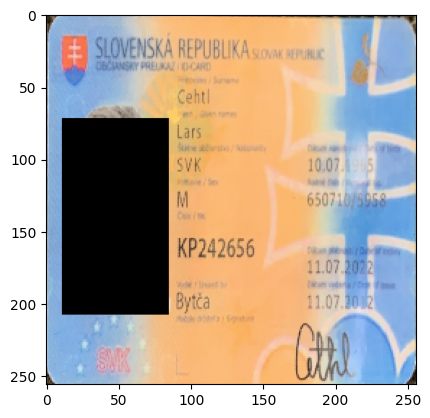

In [254]:
card = cv2.imread("template2/9.jpg")
card = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)
card = cv2.resize(card, (256, 256))
result = model.predict(card, imgsz=256, conf=0.5)[0]
boxes = [box.cpu().numpy() for box in result.boxes.xyxy]
for corners in boxes:
    corners = corners.reshape((2,2))
    center = np.mean(corners, axis=0)
    corners = center + (corners - center) * 1.3
    mask = np.ones_like(card) * 255
    mask = cv2.rectangle(mask, (int(corners[0,0]), int(corners[0,1])), (int(corners[1,0]), int(corners[1,1])), (0, 0, 0), -1)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    card = cv2.bitwise_and(card, card, mask=mask)
plt.imshow(card)

In [ ]:
_results2 = []
_ground_truth2 = []

for i in range(len(os.listdir(CARD2))):
    subfolder = os.path.join(CARD2, str(i))
    for file in os.listdir(subfolder):
        if os.path.isfile(os.path.join(subfolder, file)) == False: continue
        card = cv2.imread(os.path.join(subfolder, file))
        card = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)
        card = cv2.resize(card, (256, 256))
        card = remove_face(card)
        _results2.append(match(card, templates2))
        _ground_truth2.append(int(i))

_results2 = np.array(_results2)
_ground_truth2 = np.array(_ground_truth2)


In [40]:
threshold = 0.7

In [41]:
_labels2 = np.argmax(_results2, axis=1)
_score2 = np.max(_results2, axis=1)

_recognized2 = np.where(_score2 > threshold, 1, 0)

In [42]:
accuracy = np.sum(_labels2 == _ground_truth2) / len(_ground_truth2)
print(accuracy)

0.994535519125683


In [43]:
print(np.sum(_recognized2) / _recognized2.shape[0])

0.9617486338797814


In [96]:
from extraction import predict_corners, crop_image, document_detect

In [ ]:
fake_templates = []
for template in os.listdir("fake_template"):
    template = cv2.imread(os.path.join("fake_template", template))
    template = cv2.resize(template, (256, 256))
    brighter_template = template.copy()
    brighter_template = cv2.cvtColor(brighter_template, cv2.COLOR_RGB2HSV)
    brighter_template[:, :, 2] = cv2.add(brighter_template[:, :, 2], 50)
    brighter_template = cv2.cvtColor(brighter_template, cv2.COLOR_HSV2RGB)
    darker_template = template.copy()
    darker_template = cv2.cvtColor(darker_template, cv2.COLOR_RGB2HSV)
    darker_template[:, :, 2] = cv2.add(darker_template[:, :, 2], -50)
    darker_template = cv2.cvtColor(darker_template, cv2.COLOR_HSV2RGB)
    template = remove_face(template)
    brighter_template = remove_face(brighter_template)
    darker_template = remove_face(darker_template)
    fake_templates.append((darker_template, template, brighter_template))
fake_templates = np.array(fake_templates)

In [119]:
extract_model = YOLO("card_segmentation/runs/obb/train5/weights/best.pt")

In [120]:
from time import time
from extraction import predict_corners, crop_image, document_detect

In [121]:
image_dir = "C:/Dataset/card/datasets/train/train/images/image58.png"
start = time()
raw_image = cv2.imread(image_dir)
corners = predict_corners(extract_model, image_dir)
cropped = crop_image(raw_image, corners, expand_rate=0.1)
card = document_detect(cropped)
result = match_triple(card, fake_templates)
end = time()
print(end - start, 'seconds')


image 1/1 C:\Dataset\card\datasets\train\train\images\image58.png: 320x192 47.0ms
Speed: 15.6ms preprocess, 47.0ms inference, 2.3ms postprocess per image at shape (1, 3, 320, 192)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
2